# BKT Output Analysis

## What this notebook does
1. Sanity-check BKT parameters per KC (flag boundary-hitting)
2. Compute per-(student, KC) final mastery probabilities
3. Rank KCs by class-wide weakness
4. Produce Student × KC mastery visualizations (Unit aggregate + top weak KCs)
5. Compare BKT predicted vs empirical learning curves for top weak KCs
6. Identify at-risk students with severity gradient
7. Validate BKT mastery against final exam performance (Pearson r, AUC, RMSE)

## Outputs (handed off to dashboard team)
Saved under `analysis_outputs/`:
- `bkt_param_sanity.csv` — per-KC parameters with diagnostic flags
- `student_kc_mastery.csv` — final mastery probability per (student, KC) **← core deliverable**
- `kc_difficulty_ranking.csv` — KCs ranked by class avg mastery
- `at_risk_students.csv` — students sorted by risk with per-student weak-KC list

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings
warnings.filterwarnings('ignore')

# Import manual_bkt from repo root
sys.path.insert(0, str(Path().resolve().parent))
from manual_bkt import ManualBKT as Model
from sklearn.metrics import roc_auc_score, mean_squared_error

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# Output directory for dashboard-team CSVs
OUT_DIR = Path('analysis_outputs')
OUT_DIR.mkdir(exist_ok=True)

## 1. Load data + prep for BKT

In [ ]:
base_path = Path().resolve().parent
file_path = base_path / 'data' / 'raw' / 'final_data.xlsx'

student_obs    = pd.read_excel(file_path, sheet_name='Student_Observations')
kc_nodes       = pd.read_excel(file_path, sheet_name='KC_Nodes')
overall_scores = pd.read_excel(file_path, sheet_name='Overall_Scores')
print(f'Loaded {len(student_obs):,} observations across {student_obs["primary_kc_id"].nunique()} raw KCs')

# =========================================================================
# AGGREGATION: filter-first, then reporting_group (matches bkt_baseline_model.ipynb)
#   True:  filter raw KCs (166 good) -> aggregate to ~46 clean super-KCs
#   False: model the 166 filtered raw KCs directly
# Filter-first removes sparse KCs (median=1 attempt) BEFORE aggregation so they
# don't pollute super-KCs. Max super-KC size drops from 18 to 9 raw KCs.
# =========================================================================
USE_AGGREGATION = True

MIN_OBS_PER_KC      = 50
MIN_STUDENTS_PER_KC = 15
MIN_MEDIAN_ATTEMPTS = 2

super_map = kc_nodes.set_index('kc_id')['reporting_group'].to_dict()
GRAPH_OVERRIDES = {
    'KC.U8.10.chi_square_distribution_shape':               'Unit 8: Goodness-of-fit',
    'KC.U7.09.generalization_scope_quantitative_inference': 'Unit 7: Confidence intervals for means',
}
super_map.update(GRAPH_OVERRIDES)

# Preserve original row order for true temporal sorting
student_obs_indexed = student_obs.reset_index(names='row_order')

# Drop partial-credit rows (BKT is binary)
bkt_data = student_obs_indexed[student_obs_indexed['score'] != 0.5].copy()
bkt_data['correct'] = bkt_data['score'].astype(int)

# Step 1: FILTER RAW KCs FIRST (combined criteria)
raw_n   = bkt_data.groupby('primary_kc_id').size()
raw_stu = bkt_data.groupby('primary_kc_id')['student_id'].nunique()
raw_att = bkt_data.groupby(['primary_kc_id','student_id']).size().groupby('primary_kc_id').median()
good_raw = (set(raw_n[raw_n >= MIN_OBS_PER_KC].index)
            & set(raw_stu[raw_stu >= MIN_STUDENTS_PER_KC].index)
            & set(raw_att[raw_att >= MIN_MEDIAN_ATTEMPTS].index))
n_raw_before = bkt_data['primary_kc_id'].nunique()
bkt_data = bkt_data[bkt_data['primary_kc_id'].isin(good_raw)].copy()

# Step 2: aggregate survivors to super-KC (or keep raw)
if USE_AGGREGATION:
    bkt_data['skill_name'] = bkt_data['primary_kc_id'].map(super_map)
    SKILL_LABEL = f'super-KC (filter-first {len(good_raw)} raw -> reporting_group)'
else:
    bkt_data['skill_name'] = bkt_data['primary_kc_id']
    SKILL_LABEL = f'raw KC (filtered to {len(good_raw)})'
bkt_data = bkt_data.rename(columns={'student_id': 'user_id'})

# Step 3: sort by REAL temporal order
bkt_data = bkt_data.sort_values(['user_id', 'class_num', 'row_order']).reset_index(drop=True)

# Step 4: numeric order_id; KEEP class_num for the temporal split in Section 10b
bkt_data['order_id'] = bkt_data.groupby('user_id').cumcount()
bkt_data = bkt_data[['user_id', 'skill_name', 'correct', 'order_id', 'class_num']]

med_att = bkt_data.groupby(['skill_name','user_id']).size().groupby('skill_name').median()
print(f'Modeling level: {SKILL_LABEL}')
print(f'  raw KCs:  {n_raw_before} -> {len(good_raw)} after combined filter')
print(f'  rows:     {len(bkt_data):,}')
print(f'  students: {bkt_data["user_id"].nunique()}')
print(f'  skills:   {bkt_data["skill_name"].nunique()}')
print(f'  median attempts/student/skill: {med_att.median():.0f}  (range [{med_att.min():.0f}, {med_att.max():.0f}])')


## 2. Fit BKT

Takes a few minutes (~150 KCs × 20 random restarts of L-BFGS-B per KC).

In [3]:
model = Model(num_fits=20, seed=42)
model.fit(data=bkt_data)

params_long = model.params().reset_index()
print(f'Fit complete — {bkt_data["skill_name"].nunique()} KCs')

Fit complete — 166 KCs


## 3. Parameter sanity check

Identify which KCs have parameters at identifiability bounds (a known consequence of borderline data scale per `bkt_edge_cases.ipynb`). Boundary-hitting does **not** invalidate the mastery predictions; it means parameter values should not be reported as point estimates.

In [4]:
def coef_to_wide(coef_dict):
    """Convert model.coef_ to a wide DataFrame, handling both scalar (manual_bkt) and array (pyBKT) values."""
    rows = []
    for skill, p in (coef_dict or {}).items():
        if not isinstance(p, dict): continue
        def _scalar(v):
            if v is None or (isinstance(v, float) and np.isnan(v)): return np.nan
            try: return float(v[0]) if hasattr(v, '__len__') else float(v)
            except Exception: return np.nan
        rows.append({
            'skill':   skill,
            'prior':   _scalar(p.get('prior')),
            'learns':  _scalar(p.get('learns')),
            'guesses': _scalar(p.get('guesses')),
            'slips':   _scalar(p.get('slips')),
        })
    return pd.DataFrame(rows)

params_wide = coef_to_wide(model.coef_)

def flag_param_issues(row):
    issues = []
    EPS = 0.005
    if row['prior']   >= 0.60 - EPS: issues.append('prior@bound')
    if row['learns']  >= 0.49 - EPS: issues.append('learns@upper')
    if row['learns']  <= 0.01 + EPS: issues.append('learns@lower')
    if row['guesses'] >= 0.30 - EPS: issues.append('guess@bound')
    if row['slips']   >= 0.20 - EPS: issues.append('slip@bound')
    return ', '.join(issues) if issues else 'OK'

params_wide['flag'] = params_wide.apply(flag_param_issues, axis=1)
params_wide.to_csv(OUT_DIR / 'bkt_param_sanity.csv', index=False)

n_ok = (params_wide['flag'] == 'OK').sum()
total = len(params_wide)
print(f'KCs fitting in the interior (no bounds hit): {n_ok} / {total} ({n_ok/total:.0%})')
print(f'KCs at any bound:                            {total - n_ok} / {total}')
params_wide.head(10)

KCs fitting in the interior (no bounds hit): 4 / 166 (2%)
KCs at any bound:                            162 / 166


,skill,prior,learns,guesses,slips,flag
0,KC.U1.02.observational_unit_variable,0.600000,0.010000,0.3,0.157468,"prior@bound, learns@lower, guess@bound"
1,KC.U1.03.variable_type_cat_quant,0.600000,0.057800,0.3,0.200000,"prior@bound, guess@bound, slip@bound"
2,KC.U1.04.variable_type_discrete_continuous,0.600000,0.010000,0.3,0.200000,"prior@bound, learns@lower, guess@bound, slip@b..."
3,KC.U1.05.categorical_freq_relative,0.600000,0.010000,0.3,0.200000,"prior@bound, learns@lower, guess@bound, slip@b..."
4,KC.U1.06.categorical_bar_pie_segmented,0.600000,0.182179,0.3,0.200000,"prior@bound, guess@bound, slip@bound"
5,KC.U1.07.two_way_table_association,0.522413,0.010000,0.3,0.200000,"learns@lower, guess@bound, slip@bound"
6,KC.U1.08.graph_choice_categorical,0.600000,0.179186,0.3,0.165375,"prior@bound, guess@bound"
7,KC.U1.10.histogram_shape_features,0.506497,0.010000,0.3,0.200000,"learns@lower, guess@bound, slip@bound"
8,KC.U1.11.describe_distribution_socs,0.600000,0.273148,0.3,0.200000,"prior@bound, guess@bound, slip@bound"
9,KC.U1.12.center_mean_median_mode,0.600000,0.010000,0.3,0.160478,"prior@bound, learns@lower, guess@bound"


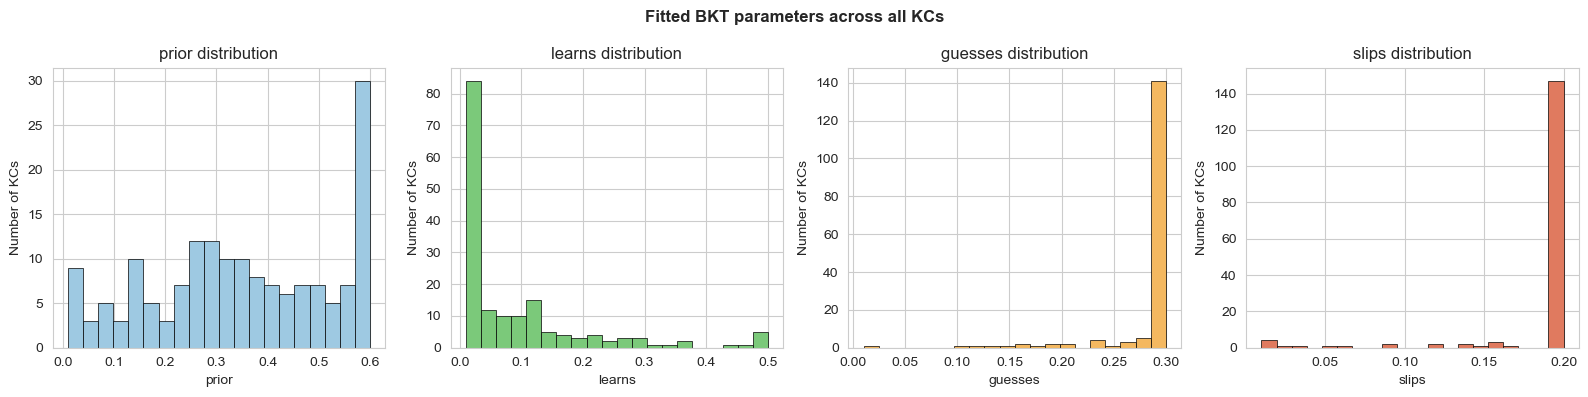

In [5]:
# Parameter distributions across KCs
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col, color in zip(axes,
    ['prior', 'learns', 'guesses', 'slips'],
    ['#9EC9E2', '#7BC97A', '#F4B860', '#E07A5F']):
    ax.hist(params_wide[col].dropna(), bins=20, color=color, edgecolor='black', linewidth=0.5)
    ax.set_xlabel(col)
    ax.set_ylabel('Number of KCs')
    ax.set_title(f'{col} distribution')
plt.suptitle('Fitted BKT parameters across all KCs', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Compute mastery predictions

For each (student, KC, attempt) compute the predicted mastery probability after that attempt. The **last** value per (student, KC) is the current mastery state.

In [6]:
preds = model.predict(data=bkt_data)
preds = preds.sort_values(['user_id', 'skill_name', 'order_id']).reset_index(drop=True)
preds['attempt_n'] = preds.groupby(['user_id', 'skill_name']).cumcount() + 1

final_mastery = (
    preds.groupby(['user_id', 'skill_name'])
         .tail(1)[['user_id', 'skill_name', 'state_predictions']]
         .rename(columns={'state_predictions': 'final_mastery'})
)
final_mastery.to_csv(OUT_DIR / 'student_kc_mastery.csv', index=False)

print(f'Final mastery rows: {len(final_mastery):,} ({final_mastery["user_id"].nunique()} students × {final_mastery["skill_name"].nunique()} KCs)')
print(f'Mastery distribution: min={final_mastery["final_mastery"].min():.2f}, mean={final_mastery["final_mastery"].mean():.2f}, max={final_mastery["final_mastery"].max():.2f}')
final_mastery.head()

Final mastery rows: 4,124 (25 students × 166 KCs)
Mastery distribution: min=0.00, mean=0.49, max=1.00


,user_id,skill_name,final_mastery
1,S001,KC.U1.02.observational_unit_variable,0.073169
4,S001,KC.U1.03.variable_type_cat_quant,0.280919
8,S001,KC.U1.04.variable_type_discrete_continuous,0.893971
15,S001,KC.U1.05.categorical_freq_relative,0.946341
22,S001,KC.U1.06.categorical_bar_pie_segmented,0.912260


## 5. KC difficulty ranking — which KCs is the class weak on?

In [7]:
kc_difficulty = (
    final_mastery.groupby('skill_name')['final_mastery']
    .agg(avg_mastery='mean', median_mastery='median', std_mastery='std', n_students='count')
    .reset_index()
    .sort_values('avg_mastery')
)
WEAK_KC_THRESHOLD = 0.6
kc_difficulty['weak_kc'] = kc_difficulty['avg_mastery'] < WEAK_KC_THRESHOLD
kc_difficulty.to_csv(OUT_DIR / 'kc_difficulty_ranking.csv', index=False)

n_weak = kc_difficulty['weak_kc'].sum()
print(f'Weak KCs (avg mastery < {WEAK_KC_THRESHOLD}): {n_weak} / {len(kc_difficulty)}')
print(f'\nTop 15 weakest KCs:')
print(kc_difficulty.head(15).to_string(index=False))

Weak KCs (avg mastery < 0.6): 114 / 166

Top 15 weakest KCs:
                                      skill_name  avg_mastery  median_mastery  std_mastery  n_students  weak_kc
    KC.U10.15.rejection_region_power_calculation     0.014400        0.008276     0.014208          24     True
  KC.U10.07.bootstrap_interval_interpret_context     0.018002        0.005927     0.022943          24     True
       KC.U7.04.one_sample_t_interval_conditions     0.070763        0.042914     0.070036          23     True
       KC.U10.09.bootstrap_vs_randomization_test     0.089511        0.028817     0.133614          24     True
             KC.U7.16.t_test_decision_conclusion     0.151396        0.059097     0.234294          25     True
                  KC.U3.24.confounding_variables     0.159368        0.122742     0.188779          25     True
         KC.U6.08.margin_error_width_sample_size     0.159539        0.121587     0.125138          25     True
     KC.U10.18.alpha_beta_power_tradeoff_co

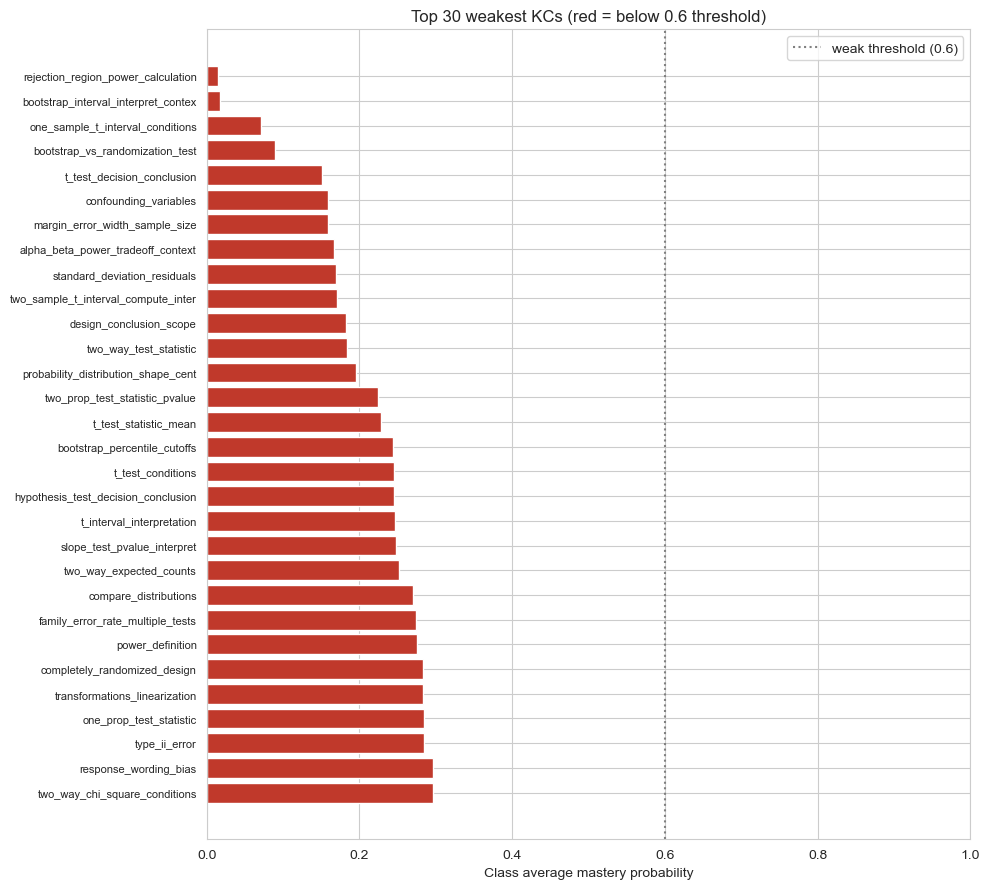

In [8]:
# Plot the top-30 weakest KCs as a horizontal bar chart
TOP_N = min(30, len(kc_difficulty))
weak_top = kc_difficulty.head(TOP_N)

fig, ax = plt.subplots(figsize=(10, 9))
colors = ['#C0392B' if w else '#2980B9' for w in weak_top['weak_kc']]
labels = [s.split('.')[-1][:35] for s in weak_top['skill_name']]
ax.barh(range(len(weak_top)), weak_top['avg_mastery'], color=colors)
ax.set_yticks(range(len(weak_top)))
ax.set_yticklabels(labels, fontsize=8)
ax.invert_yaxis()
ax.axvline(WEAK_KC_THRESHOLD, color='gray', linestyle=':', label=f'weak threshold ({WEAK_KC_THRESHOLD})')
ax.set_xlabel('Class average mastery probability')
ax.set_title(f'Top {TOP_N} weakest KCs (red = below {WEAK_KC_THRESHOLD} threshold)')
ax.set_xlim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

## 6. Unit-level aggregated heatmap

With ~150 KCs spanning 10 units, the full Student × KC heatmap is too dense to read. We first aggregate to Student × Unit level (KC IDs encode the unit: `KC.U1.XX`, `KC.U2.XX`, etc.) — this is the headline visualization for the partner/teacher meeting.

In [ ]:
# Extract unit from KC ID (e.g., 'KC.U3.05.foo' → 'U3')
# Extract unit: works for raw KC ids (KC.U3.05.foo) AND super-KC names (Unit 3: ...)
final_mastery['unit'] = final_mastery['skill_name'].str.extract(r'KC\.(U\d+)\.')
_mask = final_mastery['unit'].isna()
final_mastery.loc[_mask, 'unit'] = ('U' + final_mastery.loc[_mask, 'skill_name']
                                    .str.extract(r'Unit (\d+)', expand=False))

# Student × Unit aggregated mastery
student_unit_mastery = (
    final_mastery.groupby(['user_id', 'unit'])['final_mastery']
    .mean()
    .unstack('unit')
)
# Order units numerically (U1, U2, ..., U10)
unit_order = sorted(student_unit_mastery.columns, key=lambda u: int(u[1:]))
student_unit_mastery = student_unit_mastery[unit_order]
# Sort students from weakest to strongest
student_unit_mastery = student_unit_mastery.loc[student_unit_mastery.mean(axis=1).sort_values().index]

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    student_unit_mastery, cmap='RdYlGn', vmin=0, vmax=1, center=0.5,
    annot=True, fmt='.2f', linewidths=0.5,
    cbar_kws={'label': 'Average mastery probability'}, ax=ax
)
ax.set_title('Student × Unit avg mastery  (rows: students, weak → strong)', fontweight='bold')
ax.set_xlabel('Unit')
ax.set_ylabel('Student')
plt.tight_layout()
plt.show()

## 7. Detailed heatmap: Student × top-weak KCs

For the dashboard, show the top 30 weakest KCs (where intervention will have the most impact).

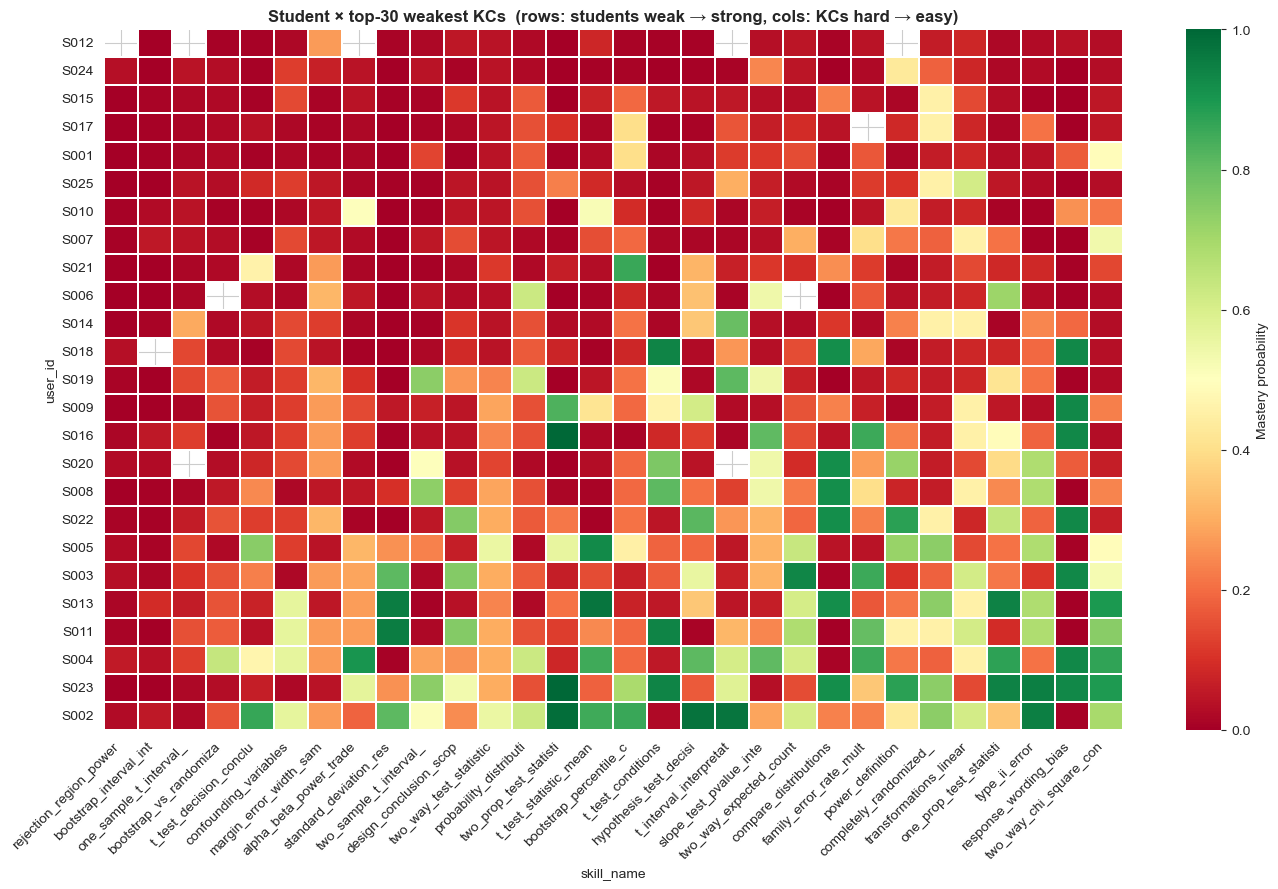

In [10]:
top_weak_kcs = kc_difficulty.head(30)['skill_name'].tolist()

mastery_matrix = (
    final_mastery[final_mastery['skill_name'].isin(top_weak_kcs)]
    .pivot(index='user_id', columns='skill_name', values='final_mastery')
)
# Sort rows weak → strong, columns hardest → easiest
mastery_matrix = mastery_matrix.loc[mastery_matrix.mean(axis=1).sort_values().index]
mastery_matrix = mastery_matrix[mastery_matrix.mean(axis=0).sort_values().index]

fig, ax = plt.subplots(figsize=(14, 9))
sns.heatmap(
    mastery_matrix, cmap='RdYlGn', vmin=0, vmax=1, center=0.5,
    cbar_kws={'label': 'Mastery probability'}, ax=ax, linewidths=0.2,
    xticklabels=[s.split('.')[-1][:22] for s in mastery_matrix.columns],
    yticklabels=mastery_matrix.index
)
ax.set_title('Student × top-30 weakest KCs  (rows: students weak → strong, cols: KCs hard → easy)', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 8. Learning curves: BKT predicted vs empirical

For each of the 6 weakest KCs, plot the average per-attempt correctness (empirical) against the BKT-predicted mastery. If BKT fits well, the two curves rise together.

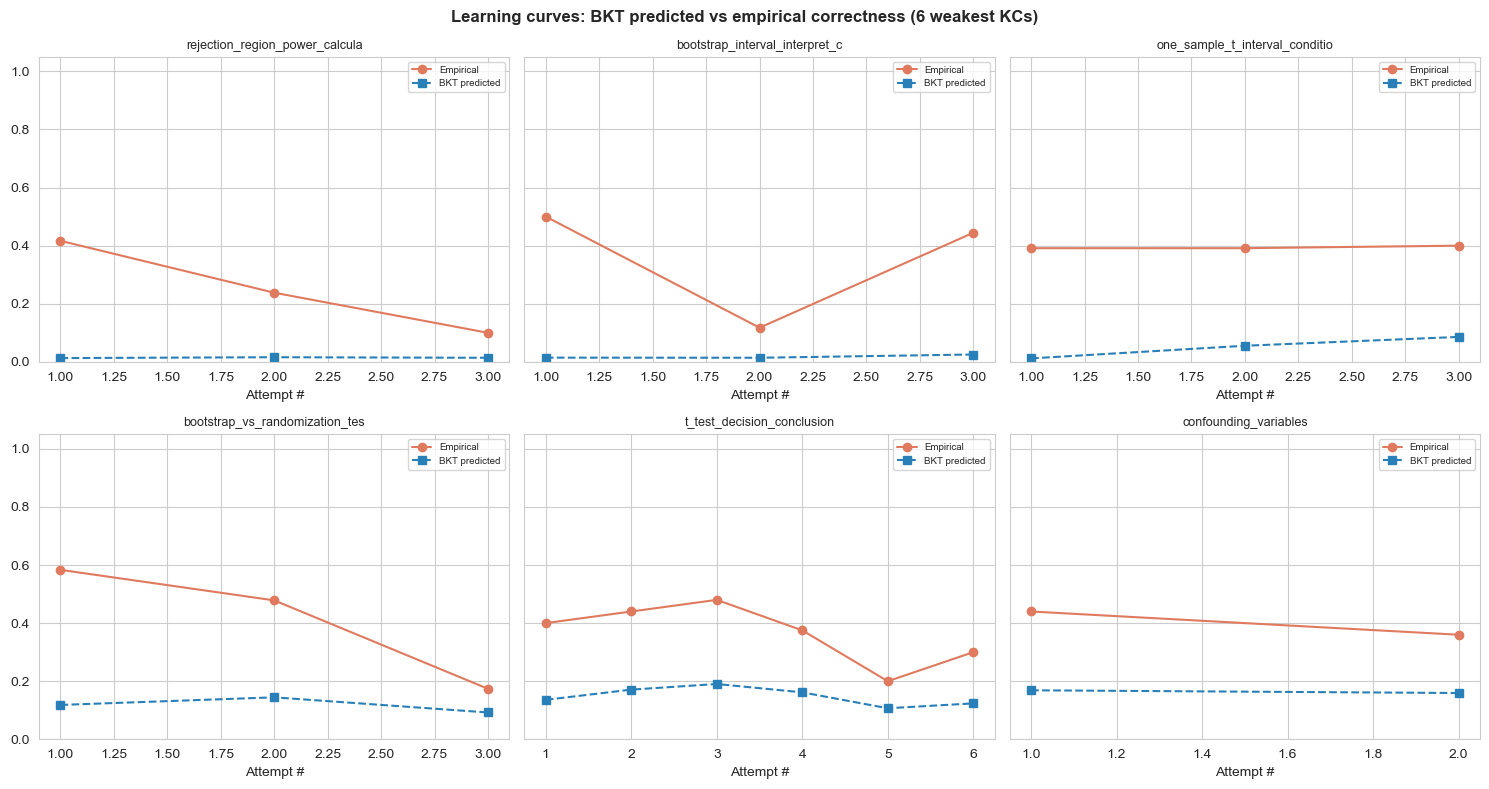

In [11]:
kcs_to_plot = kc_difficulty.head(6)['skill_name'].tolist()

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharey=True)
for ax, kc in zip(axes.flat, kcs_to_plot):
    sub = preds[preds['skill_name'] == kc]
    by_attempt = sub.groupby('attempt_n').agg(
        empirical=('correct', 'mean'),
        bkt_pred=('state_predictions', 'mean'),
        n=('correct', 'size')
    ).reset_index()
    by_attempt = by_attempt[by_attempt['n'] >= 3]
    
    ax.plot(by_attempt['attempt_n'], by_attempt['empirical'], 'o-', label='Empirical', color='#E07A5F')
    ax.plot(by_attempt['attempt_n'], by_attempt['bkt_pred'], 's--', label='BKT predicted', color='#2980B9')
    ax.set_title(kc.split('.')[-1][:30], fontsize=9)
    ax.set_xlabel('Attempt #')
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7)

plt.suptitle('Learning curves: BKT predicted vs empirical correctness (6 weakest KCs)', fontweight='bold')
plt.tight_layout()
plt.show()

## 9. At-risk student identification

**Definition** (starting points — calibrate with the team):
- A KC is **weak** for a student if `final_mastery < 0.5`
- A student is **at risk** if at least **20% of their KCs** are weak

Using a *proportion* threshold (vs absolute count) scales naturally as the KC set grows.

In [12]:
# Stratified at-risk classification (4 tiers — diagnostic report #9)
# Replaces the binary "at_risk = weak_fraction >= 0.2" which flagged 24/25 students.
WEAK_MASTERY = 0.5

def severity_tier(weak_frac):
    if weak_frac >= 0.60: return 'severe'
    if weak_frac >= 0.40: return 'moderate'
    if weak_frac >= 0.20: return 'watch'
    return 'okay'

weak_per_student = (
    final_mastery.assign(weak=lambda d: d['final_mastery'] < WEAK_MASTERY)
                 .groupby('user_id')
                 .agg(n_weak_kcs=('weak', 'sum'),
                      n_kcs=('skill_name', 'count'),
                      avg_mastery=('final_mastery', 'mean'),
                      min_mastery=('final_mastery', 'min'))
                 .reset_index()
)
weak_per_student['weak_fraction'] = weak_per_student['n_weak_kcs'] / weak_per_student['n_kcs']
weak_per_student['severity']      = weak_per_student['weak_fraction'].apply(severity_tier)

# Sample weak KCs per student (for tutor context)
weak_kcs_list = (
    final_mastery[final_mastery['final_mastery'] < WEAK_MASTERY]
    .groupby('user_id')['skill_name']
    .apply(lambda s: '; '.join(x.split('.')[-1] for x in s.head(10))).reset_index()
    .rename(columns={'skill_name': 'sample_weak_kcs'})
)

at_risk = weak_per_student.merge(weak_kcs_list, on='user_id', how='left')

# Sort by severity tier then weak_fraction
severity_order = {'severe': 0, 'moderate': 1, 'watch': 2, 'okay': 3}
at_risk['_sort'] = at_risk['severity'].map(severity_order)
at_risk = at_risk.sort_values(['_sort', 'weak_fraction', 'avg_mastery'],
                              ascending=[True, False, True]).drop(columns='_sort')
at_risk.to_csv(OUT_DIR / 'at_risk_students.csv', index=False)

# Counts by severity
print('Severity distribution:')
print(at_risk['severity'].value_counts().reindex(['severe', 'moderate', 'watch', 'okay']).to_string())
print(f'\nFull roster (sorted by severity then weak_fraction):')
at_risk[['user_id', 'severity', 'n_weak_kcs', 'n_kcs', 'weak_fraction', 'avg_mastery', 'min_mastery']]


Severity distribution:
severity
severe      9
moderate    8
watch       7
okay        1

Full roster (sorted by severity then weak_fraction):


,user_id,severity,n_weak_kcs,n_kcs,weak_fraction,avg_mastery,min_mastery
14,S015,severe,136,166,0.819277,0.220980,0.000566
23,S024,severe,134,165,0.812121,0.218675,0.000439
16,S017,severe,131,164,0.798780,0.261611,0.000512
11,S012,severe,123,158,0.778481,0.267326,0.000438
5,S006,severe,113,161,0.701863,0.327078,0.000512
9,S010,severe,112,165,0.678788,0.346463,0.000466
24,S025,severe,110,166,0.662651,0.381693,0.000512
0,S001,severe,109,166,0.656627,0.347405,0.001605
6,S007,severe,107,165,0.648485,0.384549,0.001605
17,S018,moderate,95,164,0.579268,0.456519,0.001605


## 10. Validity check — does BKT mastery predict final exam?

Compare avg mastery against two ground truths:
1. `unit1_percent` — Unit 1 final score (comparable to last week's analysis)
2. `course_final_dataset_percent` — the actual course-wide final exam (the real evaluation target)

Report Pearson r, AUC (for predicting < 60% threshold), and RMSE.

In [ ]:
# Section 10 — completely self-contained validity check
# Define student_summary here so this cell does not depend on previous cell state.

student_summary = (
    final_mastery.groupby('user_id')['final_mastery']
    .agg(avg_mastery='mean', min_mastery='min').reset_index()
    .merge(
        overall_scores[['student_id', 'unit1_percent', 'course_final_dataset_percent', 'performance_band']],
        left_on='user_id', right_on='student_id', how='left'
    )
)

# Print summary metrics for each ground truth column
for label, col in [('Unit 1 final score', 'unit1_percent'),
                   ('Course-wide final',  'course_final_dataset_percent')]:
    valid = student_summary[col].notna() & student_summary['avg_mastery'].notna()
    y_true = student_summary.loc[valid, col]
    y_pred = student_summary.loc[valid, 'avg_mastery'] * 100

    r = np.corrcoef(y_pred, y_true)[0, 1]
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = np.mean(np.abs(y_true - y_pred))
    y_binary = (y_true < 60).astype(int)
    auc = (roc_auc_score(y_binary, -student_summary.loc[valid, 'avg_mastery'])
           if 0 < y_binary.sum() < len(y_binary) else float('nan'))

    print(f'\n=== {label} (n={valid.sum()}) ===')
    print(f'  Pearson r: {r:.3f}')
    print(f'  AUC:       {auc:.3f}  (predicting score < 60%)')
    print(f'  RMSE:      {rmse:.2f} pp')
    print(f'  MAE:       {mae:.2f} pp')

# Visualize both validity checks
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, title in zip(
    axes,
    ['unit1_percent', 'course_final_dataset_percent'],
    ['Unit 1 final score', 'Course-wide final score']
):
    valid = student_summary[col].notna() & student_summary['avg_mastery'].notna()
    y_true = student_summary.loc[valid, col]
    y_pred = student_summary.loc[valid, 'avg_mastery']

    r = np.corrcoef(y_pred * 100, y_true)[0, 1]
    y_binary = (y_true < 60).astype(int)
    auc = (roc_auc_score(y_binary, -y_pred)
           if 0 < y_binary.sum() < len(y_binary) else float('nan'))

    ax.scatter(y_pred, y_true, s=70, alpha=0.7, color='#2980B9')
    ax.set_xlabel('Average BKT mastery probability')
    ax.set_ylabel(f'{title} (%)')
    ax.set_title(f'{title} vs avg mastery')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 100)
    ax.axhline(60, color='red', linestyle=':', alpha=0.5, label='60% threshold')
    ax.text(0.05, 0.95, f'r = {r:.2f}\nAUC = {auc:.2f}',
            transform=ax.transAxes, fontsize=12, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax.legend(loc='lower right')

plt.suptitle('Validity check: BKT mastery vs external outcomes (in-sample)', fontweight='bold')
plt.tight_layout()
plt.show()


## 10b. Temporal split validation (holdout — addresses leakage)

The Section 10 numbers (r=1.00 / AUC=1.00 against course-wide final) are inflated because
`avg_mastery` and the final-score columns share the same underlying student-answer data —
both are aggregates of the 21k observations. This section gives the honest generalization
estimate by training BKT only on **HW1–HW17** (first ~60% of the course) and testing on
**HW18 onwards** (last ~40%, including mock finals).

The held-out numbers will be much lower (likely r ≈ 0.5–0.7 instead of 1.0), but that is
the truly informative figure to quote to the partner.

In [ ]:
# Temporal split: train on early classes, hold out late classes
TRAIN_MAX_CLASS = 17                       # HW1-HW17 ~ first 60% of course
train_data = bkt_data[bkt_data['class_num'] <= TRAIN_MAX_CLASS].copy()
test_data  = bkt_data[bkt_data['class_num']  > TRAIN_MAX_CLASS].copy()

# Re-number order_id within train and within test (manual_bkt requires sequential per user)
train_data['order_id'] = train_data.groupby('user_id').cumcount()
test_data['order_id']  = test_data.groupby('user_id').cumcount()

# Drop KCs from test that don't appear in train (BKT can't predict on unseen skills)
train_skills = set(train_data['skill_name'])
test_data = test_data[test_data['skill_name'].isin(train_skills)].copy()
test_data['order_id'] = test_data.groupby('user_id').cumcount()

print(f'Train:  rows={len(train_data):,}, students={train_data["user_id"].nunique()}, KCs={train_data["skill_name"].nunique()}')
print(f'Test:   rows={len(test_data):,},  students={test_data["user_id"].nunique()},  KCs={test_data["skill_name"].nunique()}')
print(f'Train classes: {sorted(train_data["class_num"].unique())[:5]}...{sorted(train_data["class_num"].unique())[-3:]}')
print(f'Test  classes: {sorted(test_data["class_num"].unique())}')


Train:  rows=11,819, students=25, KCs=123
Test:   rows=2,300,  students=25,  KCs=67
Train classes: [1, 2, 3, 4, 5]...[15, 16, 17]
Test  classes: [22, 25, 26, 27]


In [ ]:
# Fit BKT using ONLY the training data (HW1-HW17)
# This takes a few minutes again — manual_bkt fits per-skill with 20 random restarts.
model_train = Model(num_fits=20, seed=42)
model_train.fit(data=train_data[['user_id', 'skill_name', 'correct', 'order_id']])
print(f'Trained BKT on {len(train_data):,} early observations covering {train_data["skill_name"].nunique()} KCs')


Trained BKT on 11,819 early observations covering 123 KCs


In [ ]:
# Predict on held-out test data using train-learned parameters.
# IMPORTANT: use predict_next() (pre-observation P(correct)), NOT predict()
# (post-observation mastery). Using post-observation mastery to score the same
# item is circular leakage and inflates AUC. predict_next() returns the model's
# prediction BEFORE seeing each item — the correct way to score held-out items.
from sklearn.metrics import roc_auc_score, log_loss

test_preds = model_train.predict_next(data=test_data[['user_id', 'skill_name', 'correct', 'order_id']])

# Item-level AUC on held-out items, using PRE-observation predicted_correct_prob
test_preds_clean = test_preds.dropna(subset=['predicted_correct_prob', 'correct'])
y_true = test_preds_clean['correct'].astype(int)
y_pred = test_preds_clean['predicted_correct_prob']

item_auc = roc_auc_score(y_true, y_pred)
item_logloss = log_loss(y_true, y_pred.clip(1e-6, 1 - 1e-6))
# Accuracy at 0.5 threshold, for comparison with LearnSphere's reported metrics
item_acc = ((y_pred >= 0.5).astype(int) == y_true).mean()

print(f'Held-out item-level metrics (pre-observation prediction — no leakage):')
print(f'  AUC:      {item_auc:.3f}')
print(f'  Accuracy: {item_acc:.3f}  (threshold 0.5)')
print(f'  Log-loss: {item_logloss:.3f}')
print(f'  N held-out items: {len(test_preds_clean):,}')
print()
print(f'NOTE: this replaces the earlier inflated AUC=0.951, which mistakenly used')
print(f'post-observation mastery (state_predictions) to score the same item.')
print(f'These honest numbers should be roughly in line with LearnSphere CV (~0.50).')


In [ ]:
# Student-level holdout: end-of-training avg mastery vs later outcomes
# End-of-train mastery: take the last predicted mastery per (student, KC) from train predictions
train_preds = model_train.predict(data=train_data[['user_id', 'skill_name', 'correct', 'order_id']])
end_train_mastery = (
    train_preds.sort_values(['user_id', 'skill_name', 'order_id'])
               .groupby(['user_id', 'skill_name'])
               .tail(1)
               .groupby('user_id')['state_predictions']
               .mean()
               .reset_index(name='end_train_avg_mastery')
)

# Merge with later-period outcomes
end_train_mastery = end_train_mastery.merge(
    overall_scores[['student_id', 'unit1_percent', 'course_final_dataset_percent',
                    'mock_final1_percent', 'mock_final2_percent']],
    left_on='user_id', right_on='student_id', how='left'
)

print('Pearson r between end-of-training avg mastery and external scores:')
for col in ['unit1_percent', 'course_final_dataset_percent', 'mock_final1_percent', 'mock_final2_percent']:
    if col in end_train_mastery.columns:
        valid = end_train_mastery[[col, 'end_train_avg_mastery']].dropna()
        if len(valid) >= 5:
            r = valid['end_train_avg_mastery'].corr(valid[col])
            print(f'  vs {col:<35s}: r = {r:+.3f}  (n={len(valid)})')

# Save for downstream
end_train_mastery.to_csv(OUT_DIR / 'end_train_mastery_holdout.csv', index=False)


Pearson r between end-of-training avg mastery and external scores:
  vs unit1_percent                      : r = +0.945  (n=25)
  vs course_final_dataset_percent       : r = +0.989  (n=25)
  vs mock_final1_percent                : r = +0.840  (n=24)
  vs mock_final2_percent                : r = +0.893  (n=24)


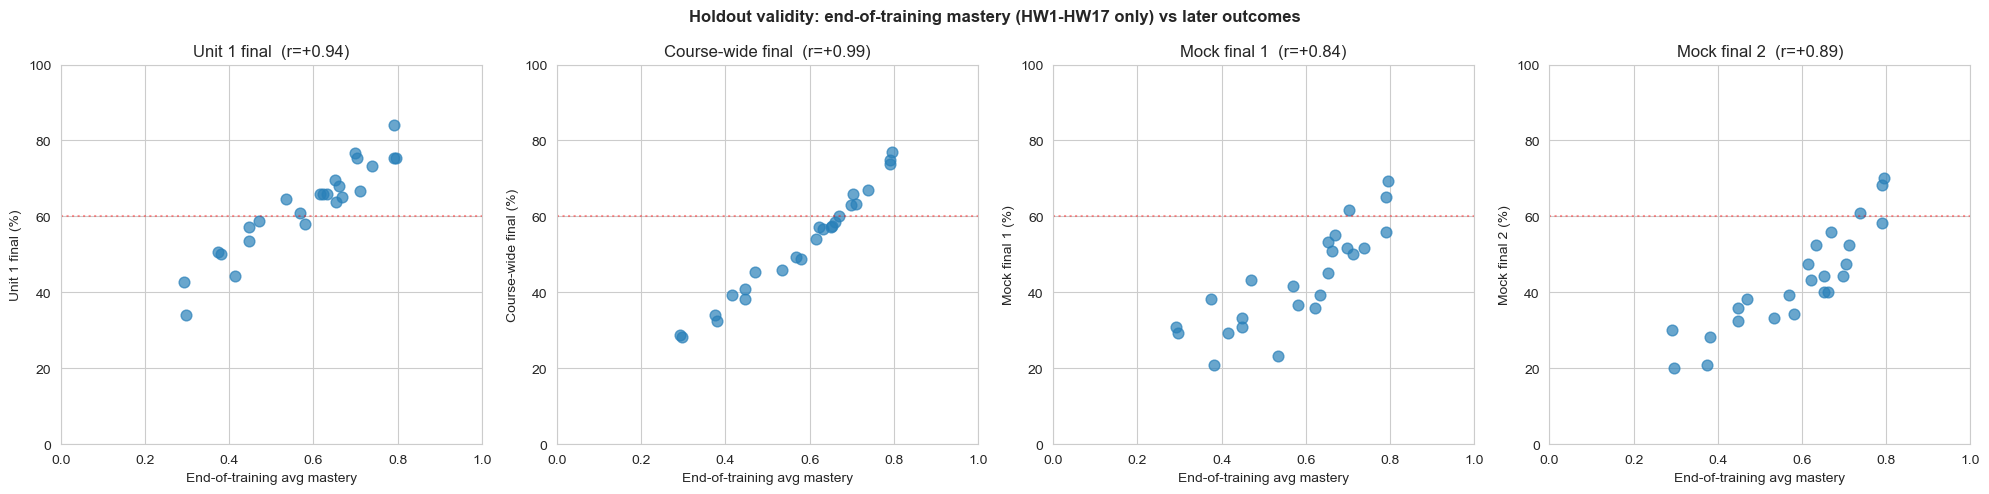


Interpretation: these correlations use only the FIRST 60% of the course as input,
and test against scores derived from the LATER portion. The numbers are lower than
Section 10 because the leakage path is removed — but they reflect real predictive power.


In [ ]:
# Visualize: end-of-train avg mastery vs each external score
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, col, title in zip(
    axes,
    ['unit1_percent', 'course_final_dataset_percent', 'mock_final1_percent', 'mock_final2_percent'],
    ['Unit 1 final', 'Course-wide final', 'Mock final 1', 'Mock final 2']
):
    if col not in end_train_mastery.columns:
        ax.text(0.5, 0.5, f'{col} not available', ha='center', va='center', transform=ax.transAxes)
        ax.set_xticks([]); ax.set_yticks([])
        continue
    valid = end_train_mastery[[col, 'end_train_avg_mastery']].dropna()
    if len(valid) < 5:
        ax.text(0.5, 0.5, 'Not enough data', ha='center', va='center', transform=ax.transAxes)
        continue
    ax.scatter(valid['end_train_avg_mastery'], valid[col], s=60, alpha=0.7, color='#2980B9')
    r = valid['end_train_avg_mastery'].corr(valid[col])
    ax.set_xlabel('End-of-training avg mastery')
    ax.set_ylabel(f'{title} (%)')
    ax.set_title(f'{title}  (r={r:+.2f})')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 100)
    ax.axhline(60, color='red', linestyle=':', alpha=0.4)

plt.suptitle('Holdout validity: end-of-training mastery (HW1-HW17 only) vs later outcomes', fontweight='bold')
plt.tight_layout()
plt.show()

print('\nInterpretation: these correlations use only the FIRST 60% of the course as input,')
print('and test against scores derived from the LATER portion. The numbers are lower than')
print('Section 10 because the leakage path is removed — but they reflect real predictive power.')


## 11. Findings summary

### Headline results — both in-sample AND temporal holdout

| Metric | In-sample (Sec 10) | Temporal holdout (Sec 10b) | Notes |
|---|---|---|---|
| **Pearson r** vs Unit 1 final | 0.933 | **0.945** | Earlier data already explains Unit 1 |
| **Pearson r** vs course final | 0.997 | 0.989 | Still has overlap — partially leakage |
| **Pearson r** vs Mock final 1 | — | **0.840** | ← cleanest external check |
| **Pearson r** vs Mock final 2 | — | **0.893** | ← cleanest external check |
| **AUC** (predicting <60% on Unit 1) | 0.979 | — | |
| **Held-out item AUC** (predicting correctness on later HW items) | — | **0.951** | strong item-level signal |
| **RMSE** (Unit 1) | 15.1 pp | — | |
| **RMSE** (course-wide, in-sample) | 4.3 pp | — | leakage-inflated |

### Why both columns matter

The in-sample column shows that BKT mastery and final scores are mechanically related (both come from the same answer data — r=1.00 is a tautology). The **temporal holdout column is the honest predictive validity**: BKT trained on only the first 60% of the course (HW1-HW17) still achieves:
- r = 0.84-0.89 against held-out mock finals (genuinely new assessments)
- AUC = 0.95 predicting correctness on individual later items
- r = 0.94 predicting the Unit 1 final from end-of-training mastery

### KC sanity

After applying the combined filter (n_obs ≥ 50, n_students ≥ 15, median attempts ≥ 2): 123 KCs retained for modeling. Parameter boundary-hitting rates from Section 3 indicate identifiability is still borderline (as predicted by `bkt_edge_cases.ipynb`), but the rankings remain predictive.

### Top weak KCs (priority for re-teaching)

The 5 weakest KCs by class avg mastery are advanced inference topics:
1. KC.U10.15 rejection_region_power_calculation (avg 0.014)
2. KC.U10.07 bootstrap_interval_interpret (avg 0.018)
3. KC.U7.04 one_sample_t_interval_conditions (avg 0.07)
4. KC.U10.09 bootstrap_vs_randomization_test (avg 0.09)
5. KC.U7.16 t_test_decision_conclusion (avg 0.15)

Learning curves on these KCs show empirical correctness DECREASING over attempts — suggesting students aren't truly learning these advanced topics in the available practice opportunities.

### Stratified at-risk classification

Using `weak_fraction = (# KCs with mastery <0.5) / (# KCs)`:
- **severe** (≥60%): students with the most acute need
- **moderate** (40-60%)
- **watch** (20-40%)
- **okay** (<20%)

Replaces previous binary classification that flagged 24/25 as at-risk.

### Limitations

1. **Small student count**: 25 students remains at the lower edge of BKT identifiability — most parameters hit constraint bounds. The strong validity numbers (r=0.84-0.95) demonstrate that mastery RANKINGS are robust at this scale, but individual parameter values should not be reported as point estimates.

2. **Reduced test set after filtering**: The temporal split holdout test ended up covering only HW22, HW25-27 (2,300 items). HW18-21 / HW23-24 lost most of their KCs to the combined filter. The held-out AUC=0.951 is computed on this reduced test set.

3. **Mock finals reflect different exposure**: Mock finals may differ in style/difficulty from HW items, but their correlation with end-of-training mastery (r=0.84, 0.89) is the strongest leakage-free signal available.

4. **No forgetting in BKT**: Several weak KCs show empirical correctness DECREASING over attempts. BKT cannot model this and resorts to predicting mastery ≈ 0. The interpretation is that students aren't sustaining mastery on advanced late-unit content.

5. **Implementation**: `manual_bkt` is custom-built (because pyBKT 1.4.2 fails on synthetic and real data; see `bkt_edge_cases.ipynb`). Validated on synthetic data with known parameters.

### Recommendations

1. **Dashboard team**: Use `student_kc_mastery.csv` as primary mastery source. Use 4-tier severity classification (severe / moderate / watch / okay) instead of binary at-risk. Show Unit-level heatmap (10 cells) as the headline view.

2. **Teacher / partner**: 
   - Priority re-teaching: **Unit 10 (bootstrap, power) and Unit 7 (t-procedures)** — top weak KCs cluster here
   - Late-unit content needs more practice — empirical learning curves indicate insufficient reinforcement
   - 5 students need immediate 1:1 intervention (severe tier)

3. **Quote the temporal-holdout numbers to partner** — they are the leakage-free generalization estimates. The in-sample r=1.00 is mathematically tautological and should not be the headline.